In [30]:
#Sidpy fitting
'''
This file will contain a class that is used for SHO fitting for sidpy datasets
for now I am just dumping the code from the notebook, but essentially this should be it's own class that is instantiated with the BEPS dataset
THen it should be able to do sho fitting and maybe loop fitting.

'''

# import numpy as np
import time
import h5py

import pyNSID
import matplotlib.pyplot as plt
import numba

import sidpy
#Let's open up a sample dataset and see...

import SciFiReaders as sr
from scipy.optimize import curve_fit
import numpy as np



def SHO_fit_flattened(wvec,*p):
    Amp, w_0, Q, phi=p[0],p[1],p[2],p[3]
    func = Amp * np.exp(1.j * phi) * w_0 ** 2 / (wvec ** 2 - 1j * wvec * w_0 / Q - w_0 ** 2)
    return np.hstack([np.real(func),np.imag(func)])

def SHO_fit_abs(wvec,*p):
    Amp, w_0, Q, phi=p[0],p[1],p[2],p[3]
    func = Amp * np.exp(1.j * phi) * w_0 ** 2 / (wvec ** 2 - 1j * wvec * w_0 / Q - w_0 ** 2)
    return np.abs(func)

def my_guess_fn(freq_vec,ydata):
    ydata = np.array(ydata)
    amp_guess = np.abs(ydata)[np.argmax(np.abs(ydata))]
    Q_guess = 50
    max_min_ratio = np.max(abs(ydata)) / np.min(abs(ydata))
    phi_guess = np.angle(ydata)[np.argmax(np.abs(ydata))]
    w_guess = freq_vec[np.argmax(np.abs(ydata))]
    
    #Let's just run some Q values to find the closest one
    Q_values = [5,10,20,50,100,200,500]
    err_vals = []
    for q_val in Q_values:
        p_test = [amp_guess/q_val, w_guess, q_val, phi_guess]
        func_out = SHO_fit_flattened(freq_vec,*p_test)
        complex_output = func_out[:len(func_out)//2] + 1j*func_out[(len(func_out)//2):] 
        amp_output = np.abs(complex_output)
        err = np.mean((amp_output - np.abs(ydata))**2)
        err_vals.append(err)
    Q_guess = Q_values[np.argmin(err_vals)]
    p0 = [amp_guess/Q_guess, w_guess, Q_guess, phi_guess]
    return p0


#Complex Gaussian Guess function
from numpy import exp, abs, sqrt, sum, real, imag, arctan2, append

def SHOestimateGuess(w_vec, resp_vec, num_points=5):
    """
    Generates good initial guesses for fitting

    Parameters
    ------------
    w_vec : 1D numpy array or list
        Vector of BE frequencies
    resp_vec : 1D complex numpy array or list
        BE response vector as a function of frequency
    num_points : (Optional) unsigned int
        Quality factor of the SHO peak

    Returns
    ---------
    retval : tuple
        SHO fit parameters arranged as amplitude, frequency, quality factor, phase
    """

    ii = np.argsort(abs(resp_vec))[::-1]

    a_mat = np.array([])
    e_vec = np.array([])
    
    for c1 in range(num_points):
        for c2 in range(c1 + 1, num_points):
            w1 = w_vec[ii[c1]]
            w2 = w_vec[ii[c2]]
            X1 = real(resp_vec[ii[c1]])
            X2 = real(resp_vec[ii[c2]])
            Y1 = imag(resp_vec[ii[c1]])
            Y2 = imag(resp_vec[ii[c2]])

            denom = (w1 * (X1 ** 2 - X1 * X2 + Y1 * (Y1 - Y2)) + w2 * (-X1 * X2 + X2 ** 2 - Y1 * Y2 + Y2 ** 2))
            if denom > 0:
                a = ((w1 ** 2 - w2 ** 2) * (w1 * X2 * (X1 ** 2 + Y1 ** 2) - w2 * X1 * (X2 ** 2 + Y2 ** 2))) / denom
                b = ((w1 ** 2 - w2 ** 2) * (w1 * Y2 * (X1 ** 2 + Y1 ** 2) - w2 * Y1 * (X2 ** 2 + Y2 ** 2))) / denom
                c = ((w1 ** 2 - w2 ** 2) * (X2 * Y1 - X1 * Y2)) / denom
                d = (w1 ** 3 * (X1 ** 2 + Y1 ** 2) -
                     w1 ** 2 * w2 * (X1 * X2 + Y1 * Y2) -
                     w1 * w2 ** 2 * (X1 * X2 + Y1 * Y2) +
                     w2 ** 3 * (X2 ** 2 + Y2 ** 2)) / denom

                if d > 0:
                    a_mat = append(a_mat, [a, b, c, d])

                    A_fit = abs(a + 1j * b) / d
                    w0_fit = sqrt(d)
                    Q_fit = -sqrt(d) / c
                    phi_fit = arctan2(-b, -a)

                    H_fit = A_fit * w0_fit ** 2 * exp(1j * phi_fit) / (
                        w_vec ** 2 - 1j * w_vec * w0_fit / Q_fit - w0_fit ** 2)

                    e_vec = append(e_vec,
                                   sum((real(H_fit) - real(resp_vec)) ** 2) +
                                   sum((imag(H_fit) - imag(resp_vec)) ** 2))
    if a_mat.size > 0:
        a_mat = a_mat.reshape(-1, 4)

        weight_vec = (1 / e_vec) ** 4
        w_sum = sum(weight_vec)

        a_w = sum(weight_vec * a_mat[:, 0]) / w_sum
        b_w = sum(weight_vec * a_mat[:, 1]) / w_sum
        c_w = sum(weight_vec * a_mat[:, 2]) / w_sum
        d_w = sum(weight_vec * a_mat[:, 3]) / w_sum

        A_fit = abs(a_w + 1j * b_w) / d_w
        w0_fit = sqrt(d_w)
        Q_fit = -sqrt(d_w) / c_w
        phi_fit = np.arctan2(-b_w, -a_w)

        H_fit = A_fit * w0_fit ** 2 * exp(1j * phi_fit) / (w_vec ** 2 - 1j * w_vec * w0_fit / Q_fit - w0_fit ** 2)

        if np.std(abs(resp_vec)) / np.std(abs(resp_vec - H_fit)) < 1.2 or w0_fit < np.min(w_vec) or w0_fit > np.max(
                w_vec):
            p0 = SHOfastGuess(w_vec, resp_vec)
        else:
            p0 = np.array([A_fit, w0_fit, Q_fit, phi_fit])
    else:
        p0 = SHOfastGuess(w_vec, resp_vec)

    return p0

def SHOfastGuess(w_vec, resp_vec, qual_factor=200):
    """
    Default SHO guess from the maximum value of the response

    Parameters
    ------------
    w_vec : 1D numpy array or list
        Vector of BE frequencies
    resp_vec : 1D complex numpy array or list
        BE response vector as a function of frequency
    qual_factor : float
        Quality factor of the SHO peak

    Returns
    -------
    retval : 1D numpy array
        SHO fit parameters arranged as [amplitude, frequency, quality factor, phase]
    """
    amp_vec = abs(resp_vec)
    i_max = int(len(resp_vec) / 2)
    return np.array([np.mean(amp_vec) / qual_factor, w_vec[i_max], qual_factor, np.angle(resp_vec[i_max])])


#Now let's fit them all with sidpy
#Let's try sidpy fitter
#Instantiate the SidFitter class
"""
p0 = SHOestimateGuess(freq_vec, ydata)

lb = [1E-6, freq_vec.min(), 50, -2*np.pi]
ub = [1E-3, freq_vec.max(), 500, 2*np.pi]


fitter = sidpy.proc.fitter.SidFitter(beps_small, SHO_fit_flattened,num_workers=1,
                                     guess_fn = SHOestimateGuess,ind_dims=[0,1,3,4],
                           threads=1, return_cov=False, return_fit=False, return_std=False,
                           km_guess=True,num_fit_parms = 4, n_clus = 5)

n_workers = 8
    #for n_workers in [2,4,8]:
        
fitter = sidpy.proc.fitter.SidFitter(beps_small, SHO_fit_flattened,num_workers=n_workers,
                                     guess_fn = SHOestimateGuess,ind_dims=[0,1,3,4],
                           threads=1, return_cov=False, return_fit=False, return_std=False,
                           km_guess=True,num_fit_parms = 4, n_clus = 4)
"""

'\np0 = SHOestimateGuess(freq_vec, ydata)\n\nlb = [1E-6, freq_vec.min(), 50, -2*np.pi]\nub = [1E-3, freq_vec.max(), 500, 2*np.pi]\n\n\nfitter = sidpy.proc.fitter.SidFitter(beps_small, SHO_fit_flattened,num_workers=1,\n                                     guess_fn = SHOestimateGuess,ind_dims=[0,1,3,4],\n                           threads=1, return_cov=False, return_fit=False, return_std=False,\n                           km_guess=True,num_fit_parms = 4, n_clus = 5)\n\nn_workers = 8\n    #for n_workers in [2,4,8]:\n\nfitter = sidpy.proc.fitter.SidFitter(beps_small, SHO_fit_flattened,num_workers=n_workers,\n                                     guess_fn = SHOestimateGuess,ind_dims=[0,1,3,4],\n                           threads=1, return_cov=False, return_fit=False, return_std=False,\n                           km_guess=True,num_fit_parms = 4, n_clus = 4)\n'

In [31]:
import h5py
import sidpy
import numpy as np
from sidpy.sid import Dataset, Dimension
import matplotlib.pyplot as plt
from sidpy.proc.fitter import SidFitter
import time
from sklearn.metrics import r2_score
from joblib import Parallel, delayed
import os

Raw_Data shape: (10000, 31744)
nx=100, ny=100
ncycle, ndc, nfield, nfreq:  8 32 2 62
raw_phys shape: (100, 100, 8, 32, 2, 62)
sidpy.Dataset of type IMAGE_STACK with:
 dask.array<array, shape=(100, 100, 8, 32, 2, 62), dtype=complex64, chunksize=(32, 32, 8, 32, 2, 32), chunktype=numpy.ndarray>
 data contains: generic (a.u.)
 and Dimensions: 
y:  generic (px) of size (100,)
x:  generic (px) of size (100,)
cycle:  generic (idx) of size (8,)
DC_bias:  generic (V) of size (32,)
field:  generic (idx) of size (2,)
frequency:  generic (Hz) of size (62,)


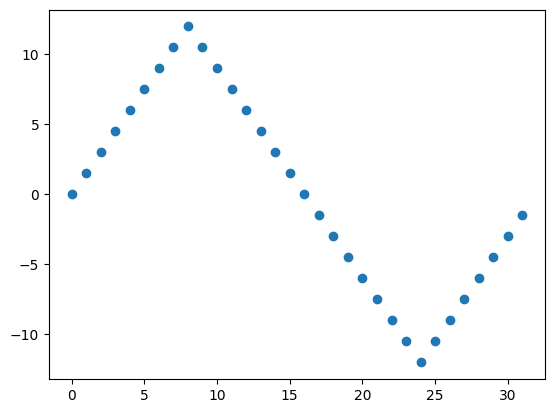

In [32]:
exp_no = '1a'

input_file = "inputs/data/BEPS_1d7um_0009.h5"
h5_f = h5py.File(input_file, 'r')

raw_data = np.array(h5_f['/Measurement_000/Channel_000/Raw_Data'])
pos_vals = np.array(h5_f['/Measurement_000/Channel_000/Position_Values'])
spec_vals = np.array(h5_f['/Measurement_000/Channel_000/Spectroscopic_Values'])
print("Raw_Data shape:", raw_data.shape)

x_vals_full = pos_vals[:, 1]
y_vals_full = pos_vals[:, 0]
x_vals = np.unique(x_vals_full)
y_vals = np.unique(y_vals_full)
nx, ny = len(x_vals), len(y_vals)
print(f"nx={nx}, ny={ny}")

ny, nx, ncycle, ndc, nfield, nfreq = 100, 100, 8, 32, 2, 62

freq = spec_vals[0, :].reshape(ncycle, ndc, nfield, nfreq)[0,0,0,:]
dc_bias = spec_vals[1, :].reshape(ncycle, ndc, nfield, nfreq)[0,:,0,0]
field = spec_vals[2, :].reshape(ncycle, ndc, nfield, nfreq)[0,0,:,0]
cycle = spec_vals[3, :].reshape(ncycle, ndc, nfield, nfreq)[:,0,0,0]

ncycle, ndc, nfield, nfreq = len(cycle), len(dc_bias), len(field), len(freq)
print('ncycle, ndc, nfield, nfreq: ', ncycle, ndc, nfield, nfreq)

a = dc_bias
plt.scatter(np.arange(len(a)), a)

raw_phys = raw_data.reshape(ny, nx, ncycle, ndc, nfield, nfreq)
# raw_phys = np.transpose(raw_phys, (1, 0, 5, 3, 4, 2)) # (nx, ny, n_freq, n_dc, n_field, n_cycle)
print("raw_phys shape:", raw_phys.shape)  

beps_raw = Dataset.from_array(raw_phys, title='BEPS Raw Data')
beps_raw.data_type = 'image_stack'
beps_raw.units = 'a.u.'
beps_raw.set_dimension(0, Dimension(y_vals, name='y', units='px'))
beps_raw.set_dimension(1, Dimension(x_vals, name='x', units='px'))
beps_raw.set_dimension(2, Dimension(cycle, name='cycle', units='idx'))
beps_raw.set_dimension(3, Dimension(dc_bias, name='DC_bias', units='V'))
beps_raw.set_dimension(4, Dimension(field, name='field', units='idx'))
beps_raw.set_dimension(5, Dimension(freq, name='frequency', units='Hz'))

print(beps_raw)

In [33]:
_nx, _ny = 50, 50
beps_raw_clean = beps_raw[50:50+_ny, 20:20+_nx, :, :, :, :] ## y to be 50:100, x to be 20:70 
print(beps_raw_clean.shape)

def add_spatial_noise(beps_raw_clean, r_noisy=0.3):
    ny, nx = beps_raw_clean.shape[:2]
    coords = np.array([[i, j] for i in range(nx) for j in range(ny)])
    row_norm = coords[:, 0] / coords[:, 0].max()
    col_norm = coords[:, 1] / coords[:, 1].max()
    noisy_score = row_norm * col_norm
    noisy_score = (noisy_score - noisy_score.min()) / (noisy_score.max() - noisy_score.min())

    threshold = np.quantile(noisy_score, 1 - r_noisy)
    noisy_indices = np.where(noisy_score >= threshold)[0]

    noise_map = np.zeros((ny, nx))
    noise_map[coords[noisy_indices, 0], coords[noisy_indices, 1]] = noisy_score[noisy_indices]

    real_noise = np.random.normal(0, 1, size=beps_raw_clean.shape)
    imag_noise = np.random.normal(0, 1, size=beps_raw_clean.shape)
    complex_noise = (real_noise + 1j * imag_noise) * noise_map[:, :, None, None, None, None]
    beps_raw_noisy = beps_raw_clean + complex_noise

    return beps_raw_noisy, noise_map, noisy_indices, noisy_score

beps_raw_noisy, noisy_map, noisy_indices, noisy_score = add_spatial_noise(beps_raw_clean)

print(beps_raw_noisy.shape, noisy_map.shape, noisy_indices.shape, noisy_score.shape)

(50, 50, 8, 32, 2, 62)
(50, 50, 8, 32, 2, 62) (50, 50) (751,) (2500,)


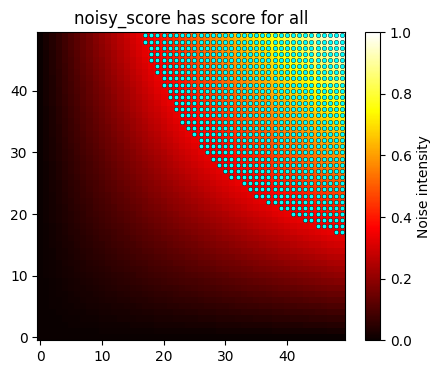

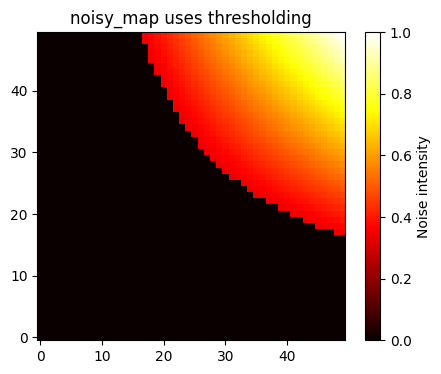

(50, 50, 8, 32, 2, 62) (50, 50, 8, 32, 2, 62)


In [34]:
# visualize noise map
plt.figure(figsize=(5,4))
plt.imshow(noisy_score.reshape(_ny, _nx), cmap='hot', origin='lower') ## hot, inferno, viridis
plt.colorbar(label='Noise intensity')
coords = np.array([[_y, _x] for _y in range(noisy_map.shape[0]) for _x in range(noisy_map.shape[1])])
noisy_yx = coords[noisy_indices]
plt.scatter(noisy_yx[:,1], noisy_yx[:,0], s=10, c='cyan', edgecolors='k', linewidths=0.3)
plt.title('noisy_score has score for all')
plt.xlabel('')
plt.ylabel('')
plt.show()

# visualize noise map
plt.figure(figsize=(5,4))
plt.imshow(noisy_map, cmap='hot', origin='lower') ## hot, inferno, viridis
plt.colorbar(label='Noise intensity')
plt.title('noisy_map uses thresholding')
plt.xlabel('')
plt.ylabel('')
plt.show()

print(beps_raw_noisy.shape, beps_raw_clean.shape)

In [35]:
## save noisy indices

In [36]:
os.makedirs("outputs", exist_ok=True)
np.savez_compressed(
    f"outputs/{exp_no}_noise_info.npz",
    noisy_indices=noisy_indices,
    noisy_map=noisy_map,
    noisy_score=noisy_score
)